<a href="https://colab.research.google.com/github/AIML-Dept/Prajwal_T_Raj_1GA23AI034/blob/main/Quantum_Tutorial_4_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install -q qiskit qiskit-aer pylatexenc matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.7 MB/s eta 0:00:00


In [7]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram, plot_state_city
from qiskit_aer import AerSimulator

# Initialize AerSimulator
simulator = AerSimulator()

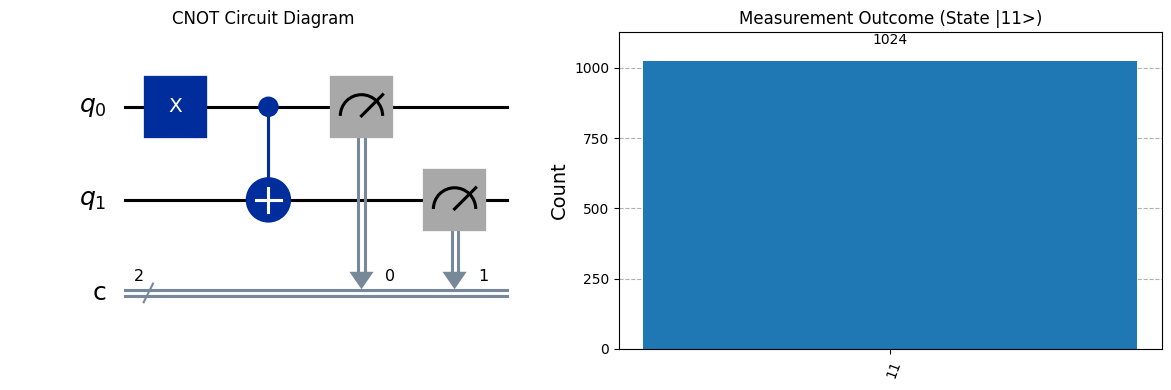

In [8]:
#Exercise 1: CNOT Gate with $\vert{}1\rangle$ Control (Easy)
# Create circuit with 2 qubits and 2 classical bits
qc_cnot = QuantumCircuit(2, 2)
qc_cnot.x(0)  # Set control qubit (q0) to |1>
qc_cnot.cx(0, 1)  # CNOT: q0 is control, q1 is target
qc_cnot.measure([0, 1], [0, 1])

# Simulation
counts_cnot = simulator.run(transpile(qc_cnot, simulator), shots=1024).result().get_counts()

# Visualizations
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
qc_cnot.draw("mpl", ax=ax[0])
ax[0].set_title("CNOT Circuit Diagram")
plot_histogram(counts_cnot, ax=ax[1])
ax[1].set_title("Measurement Outcome (State |11>)")
plt.tight_layout()
plt.show()

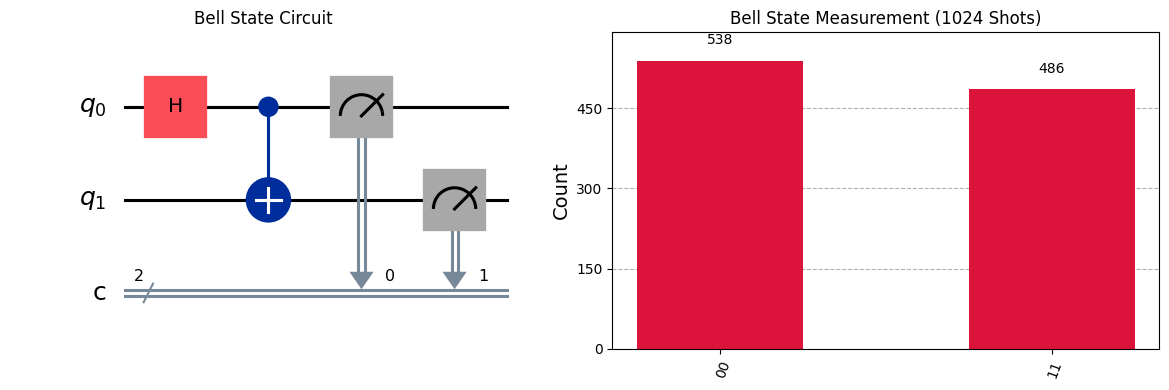

In [9]:
# Exercise 2: Bell State Generation ($\vert{}\Phi^+\rangle$) (Medium)
# Create Bell State circuit
qc_bell = QuantumCircuit(2, 2)
qc_bell.h(0)  # Superposition on q0
qc_bell.cx(0, 1)  # Entangle q0 and q1
qc_bell.measure([0, 1], [0, 1])

# Simulation with 1024 shots
counts_bell = simulator.run(transpile(qc_bell, simulator), shots=1024).result().get_counts()

# Visualizations
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
qc_bell.draw("mpl", ax=ax[0])
ax[0].set_title("Bell State Circuit")
plot_histogram(counts_bell, ax=ax[1], color="crimson")
ax[1].set_title("Bell State Measurement (1024 Shots)")
plt.tight_layout()
plt.show()

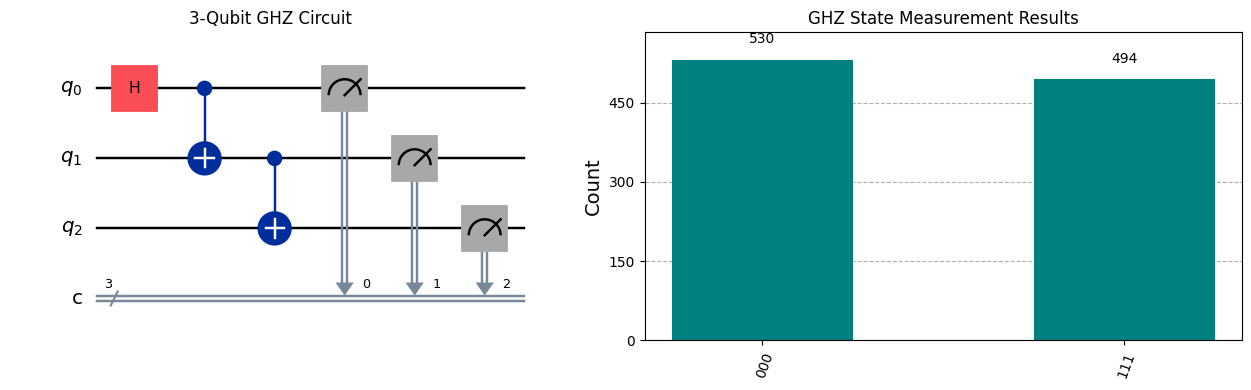

In [10]:
# Exercise 3: 3-Qubit GHZ State (Hard)
# Create GHZ State circuit
qc_ghz = QuantumCircuit(3, 3)
qc_ghz.h(0)
qc_ghz.cx(0, 1)
qc_ghz.cx(1, 2)
qc_ghz.measure([0, 1, 2], [0, 1, 2])

# Simulation
counts_ghz = simulator.run(transpile(qc_ghz, simulator), shots=1024).result().get_counts()

# Visualizations
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
qc_ghz.draw("mpl", ax=ax[0])
ax[0].set_title("3-Qubit GHZ Circuit")
plot_histogram(counts_ghz, ax=ax[1], color="teal")
ax[1].set_title("GHZ State Measurement Results")
plt.tight_layout()
plt.show()

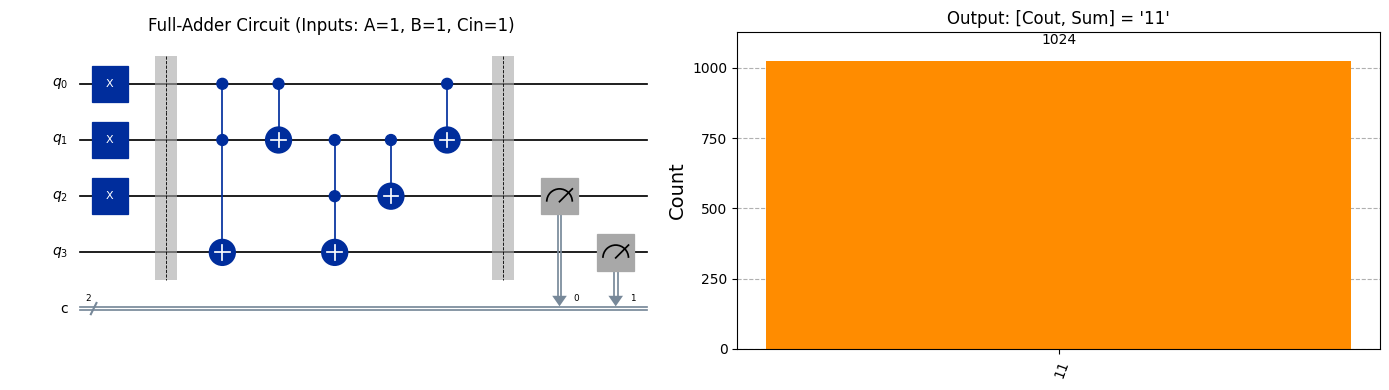

In [11]:
# Exercise 4: Classical Full-Adder Circuit (Real-World)
# Full-Adder: q0=A, q1=B, q2=Cin, q3=Cout (Helper/Output)
qc_adder = QuantumCircuit(4, 2)

# Set Input values: A=1, B=1, Cin=1
qc_adder.x(0)
qc_adder.x(1)
qc_adder.x(2)
qc_adder.barrier()

# Compute Carry-out using Toffoli gates
qc_adder.ccx(0, 1, 3)
qc_adder.cx(0, 1)
qc_adder.ccx(1, 2, 3)
qc_adder.cx(1, 2)  # q2 now holds Sum
qc_adder.cx(0, 1)  # Restore qubit 1
qc_adder.barrier()

# Measure Sum (q2) into bit 0, Cout (q3) into bit 1
qc_adder.measure(2, 0)
qc_adder.measure(3, 1)

# Simulation
counts_adder = simulator.run(transpile(qc_adder, simulator), shots=1024).result().get_counts()

# Visualizations
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
qc_adder.draw("mpl", ax=ax[0])
ax[0].set_title("Full-Adder Circuit (Inputs: A=1, B=1, Cin=1)")
plot_histogram(counts_adder, ax=ax[1], color="darkorange")
ax[1].set_title("Output: [Cout, Sum] = '11'")
plt.tight_layout()
plt.show()

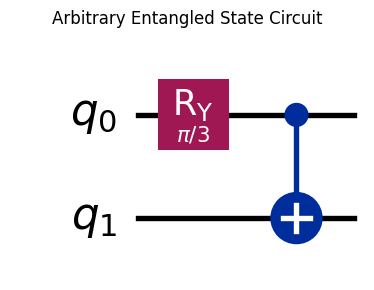

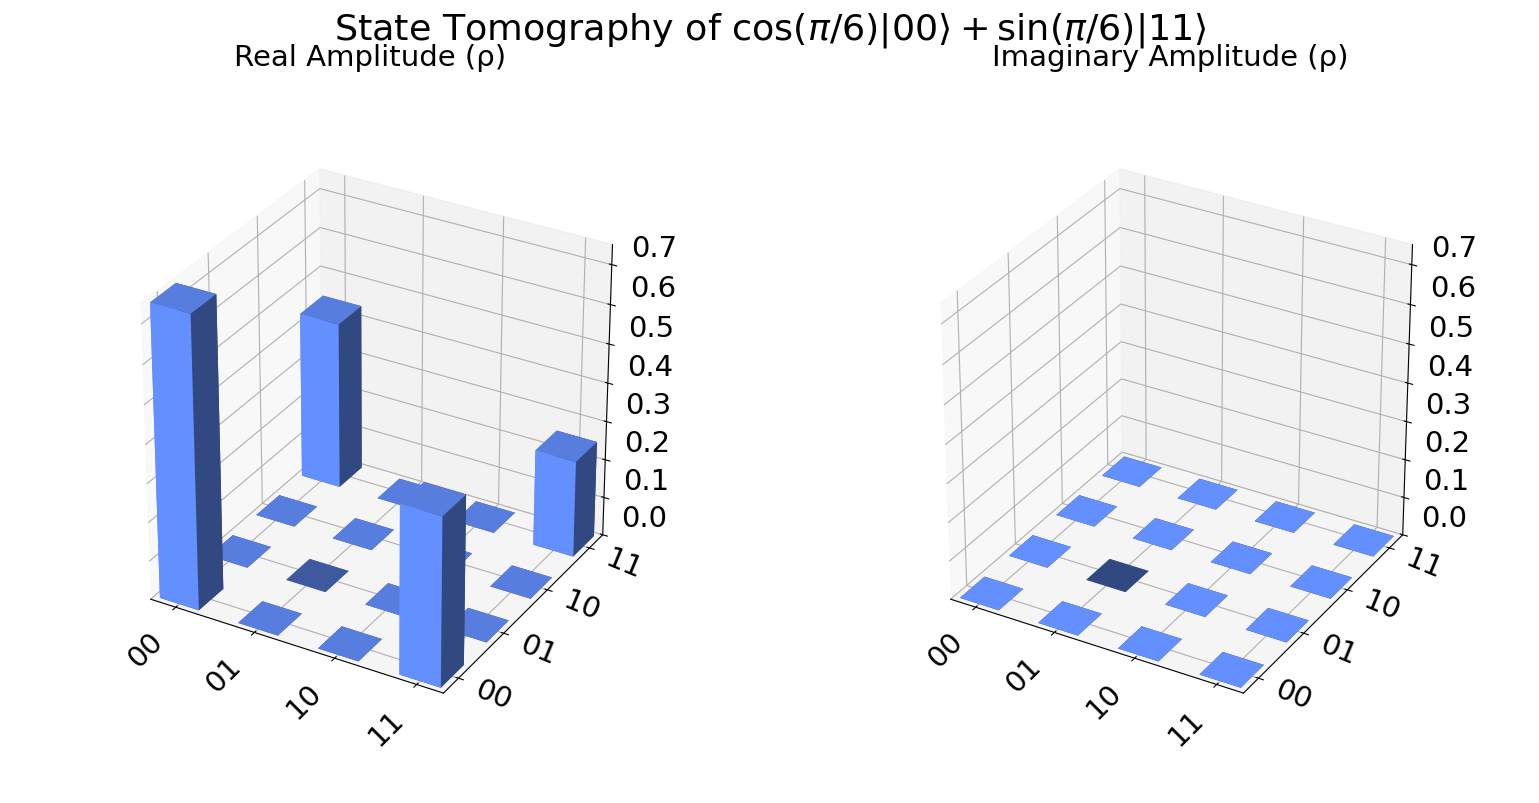

In [16]:
# Exercise 5: Arbitrary Entangled State & State Tomography (Challenge)
# Arbitrary entangled state: cos(theta)|00> + sin(theta)|11>
import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_city
from IPython.display import display

theta = np.pi / 6
qc_arb = QuantumCircuit(2)
qc_arb.ry(2 * theta, 0)
qc_arb.cx(0, 1)

# Extract Statevector
state = Statevector.from_instruction(qc_arb)

# 2D Circuit Diagram
fig_circuit, ax_circuit = plt.subplots(1, 1, figsize=(6, 3))
qc_arb.draw("mpl", ax=ax_circuit)
ax_circuit.set_title("Arbitrary Entangled State Circuit")
plt.tight_layout()
plt.show()

# 3D Density Matrix City Plot
fig_state_city = plot_state_city(state, title=r"State Tomography of $\cos(\pi/6)|00\rangle + \sin(\pi/6)|11\rangle$")
display(fig_state_city)